# Figure4

In [1]:
tag_idx = int(input("INPUT 'visualization_target for Tag RUN_ID'(e.g., 100): "))
print(f'Figure will be drawn based on the run_id_{tag_idx} dataset')

Figure will be drawn based on the run_id_100 dataset


In [2]:
import os 
import numpy as np
import pandas as pd
from datetime import datetime

from setting_for_sda.color_setting import Color_Setting
from setting_for_sda.path_setting import path_list

import lib.stats.stats as st
from lib.utils.statistics import *
from matplotlib import pyplot as plt

from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
from lib.visualization.plot_generator import PlotGen
from lib.topic_modeling.result_prep import Result_Prep as Result_Prep_Topic
from lib.tag_analysis.result_prep import Result_Prep as Result_Prep_Tag
import lib.visualization.figure_setting as figure_setting
from lib.visualization.distribution_collector import (proportion_calc_for_topic, 
                                                      collect_top_bottom_topic, 
                                                      get_distribution_by_list,
                                                      calc_top_bottom_tags_prop)
mpl.rcParams.update(figure_setting.fig_setting)
from lib.utils.datetime_handler import calc_rel_period
import statsmodels.formula.api as smf
from scipy import stats
from adjustText import adjust_text  # pip install adjustText

## Load Data

In [3]:
# load for language-level analysis
lang_df = pd.DataFrame()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    rp_tag = Result_Prep_Tag(tag_idx+idx, model_in_run='tag')
    tmp =rp_tag.data_prep()
    tmp = rp_tag.compute_N_by_week(tmp, weight_col='pct', lang = lang)
    lang_df = pd.concat([lang_df, tmp], axis = 0)
    

In [4]:
# load for total-level analysis
tot_df = pd.DataFrame()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    rp_tag = Result_Prep_Tag(tag_idx+idx, model_in_run='tag', lang=lang)
    tmp = rp_tag.get_origin_data()
    tot_df = pd.concat([tot_df, tmp], axis=0)
df_for_tot = tot_df.groupby(['rel_week'])['id'].count().reset_index(name='n_docs')

self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/python/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/javascript/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/java/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/c#/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/c++/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/c/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/r/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/php/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/swift/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/publi

# Prep for analysis

### language level analysis

In [5]:
lang_df["post"]   = (lang_df["rel_week"] >= 0).astype(int)
lang_df["t"]      = lang_df["rel_week"]
lang_df["post_t"] = lang_df["post"] * lang_df["rel_week"]
lang_df["log_y"]  = np.log(lang_df["n_docs"] + 1)

formula = ("log_y ~ t + post + post_t "
           "+ C(language) + C(language):post + C(language):post_t")
print(formula)
m = smf.ols(formula, data=lang_df).fit(
    cov_type="cluster", cov_kwds={"groups": lang_df["language"]}
)


log_y ~ t + post + post_t + C(language) + C(language):post + C(language):post_t


In [6]:
pat_post = re.compile(r"C\(language\)\[T\.(.+?)\]:post$")
interaction_post = {pat_post.match(n).group(1): v 
                    for n, v in m.params.items() if pat_post.match(n)}

all_langs = list(lang_df["language"].unique())
baseline_lang = [l for l in all_langs if l not in interaction_post][0]

# 언어별 level effect (참고용)
effects = {baseline_lang: m.params["post"]}
for lang, inter in interaction_post.items():
    effects[lang] = m.params["post"] + inter
eff_series = pd.Series(effects)

pre_data = lang_df[lang_df["post"]==0].groupby("language")['n_docs'].sum().reset_index()
pre_data['log_n_docs'] = np.log(pre_data['n_docs'] + 1)

pat_post_t = re.compile(r"C\(language\)\[T\.(.+?)\]:post_t$")
interaction_post_t = {pat_post_t.match(n).group(1): v 
                      for n, v in m.params.items() if pat_post_t.match(n)}

# 각 언어의 총 slope change = baseline의 post_t + 해당 언어의 상호작용
slope_effects = {baseline_lang: m.params["post_t"]}
for lang, inter in interaction_post_t.items():
    slope_effects[lang] = m.params["post_t"] + inter

slope_df = pd.DataFrame(list(slope_effects.items()), columns=["language", "slope_change"])
slope_df['weekly_pct'] = (np.exp(slope_df['slope_change']) - 1) * 100
slope_summary = pd.merge(slope_df, pre_data, on="language")

x_vals = slope_summary["log_n_docs"]
y_vals = slope_summary["weekly_pct"]  # weekly % change (negative)
langs = slope_summary["language"]
df_for_lang = pd.DataFrame({'x': x_vals, 'y': y_vals, 'label': langs})

x = df_for_lang['x'].values
y = df_for_lang['y'].values

slope, intercept, r, p, se = stats.linregress(x, y)
xx = np.linspace(x.min(), x.max(), 100)
yy = slope * xx + intercept

# 95% CI band (선형회귀 예측 신뢰구간)
n = len(x)
x_mean = x.mean()
ss_x = np.sum((x - x_mean)**2)
resid = y - (slope * x + intercept)
s_err = np.sqrt(np.sum(resid**2) / (n - 2))
t_val = stats.t.ppf(0.975, n - 2)
ci = t_val * s_err * np.sqrt(1/n + (xx - x_mean)**2 / ss_x)


### total level analysis

In [7]:
# VALUE_COL    = 'n_docs'                       
# TIME_COL     = 'rel_week'                    
# YLABEL       = r'Count ($\times 10^{3}$)'   
# XLABEL       = 'Weeks relative to ChatGPT release' 
# EVENT_LABEL  = 'Event'                     
SMOOTH_WIN   = 8                             
Y_SCALE      = 1000                          

# # OUT_PNG = 'figure.png'
# # OUT_PDF = 'figure.pdf'



df_for_tot = df_for_tot.sort_values('rel_week').reset_index(drop=True)
x_tot = df_for_tot['rel_week'].values
y_tot = df_for_tot['n_docs'].values.astype(float)

y_smooth = pd.Series(y_tot).rolling(SMOOTH_WIN, center=True, min_periods=1).mean().values
y_std    = pd.Series(y_tot).rolling(SMOOTH_WIN, center=True, min_periods=1).std().values

slope=-0.1889, R²=0.5804, p=1.01e-06


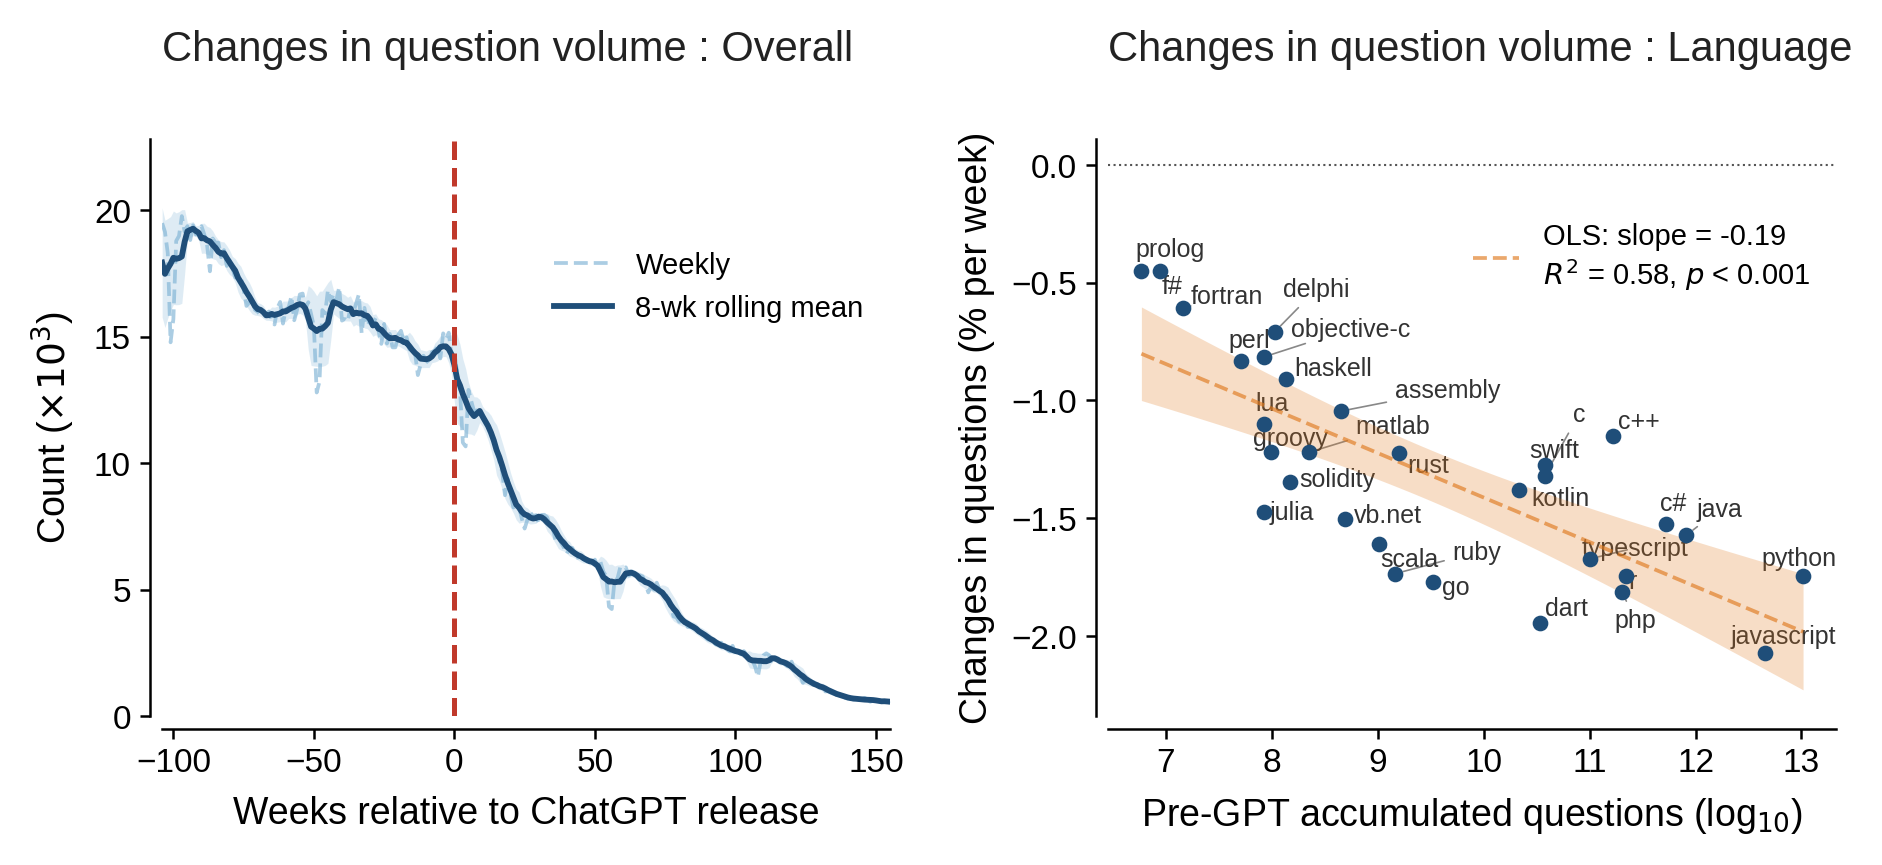

In [8]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(7.2, 2.5), dpi=300)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.3)

# a: 3패널 (각 2칸씩)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])


plotgen = PlotGen()

plotgen.draw_line_plot(ax_a, x_tot, y_tot, color=figure_setting.PALETTE['primary_light'], label='Weekly', opt='overall')
plotgen.fill_confidence_interval(ax_a, x_tot, y_smooth - y_std, y_smooth + y_std, 
                                 color=figure_setting.PALETTE['primary_light'])
# Smoothed line
ax_a.plot(x_tot, y_smooth, color=figure_setting.PALETTE['primary'], lw=1.4,
          label=f'{SMOOTH_WIN}-wk rolling mean', zorder=5)

plotgen.draw_chatgpt_line(ax_a)

plotgen.set_spine_visible(ax_a)


# 축 라벨
ax_a.set_xlabel('Weeks relative to ChatGPT release' )
ax_a.set_ylabel(r'Count ($\times 10^{3}$)'   )

# y축 스케일링 (×10³ 표기)
yticks = ax_a.get_yticks()
ax_a.set_yticks(yticks)
ax_a.set_yticklabels([f'{t/1000:g}' for t in yticks])
ax_a.set_xlim(x_tot.min(), x_tot.max())
ax_a.set_ylim(0, np.nanmax(y_tot) * 1.05 * 1.1)

ax_a.legend(loc='upper right', bbox_to_anchor=(1, 0.85), fontsize = 7)
plotgen.set_title_two_lines(ax_a, title_text='Changes in question volume : Overall')
#=====================================================================================================

plotgen.draw_line_plot(ax_b, xx, yy, 
                                 color=figure_setting.PALETTE['accent'],         
                                 label=f'OLS: slope = {slope:.2f}\n$R^2$ = {r**2:.2f}, $p$ < 0.001'
                                    if p < 0.001 else
                                    f'OLS: slope = {slope:.2f}\n$R^2$ = {r**2:.2f}, $p$ = {p:.3f}',
                                    opt='overall'
                                    )


plotgen.fill_confidence_interval(ax_b, xx, yy - ci, yy + ci, 
                                 color=figure_setting.PALETTE['accent'])




# 0 reference
ax_b.axhline(0, color=figure_setting.PALETTE['neutral'], lw=0.5, ls=':', zorder=0)

# Scatter 
ax_b.scatter(df_for_lang.loc[:, 'x'], df_for_lang.loc[:, 'y'],
           s=10, facecolor=figure_setting.PALETTE['primary'], edgecolor=figure_setting.PALETTE['primary'],
           linewidth=0.6, zorder=5)

# 라벨 — adjustText로 자동 회피 + leader line
texts = []
for _, row in df_for_lang.iterrows():
    weight = 'normal'
    color  = '#333'
    texts.append(ax_b.text(row['x'], row['y'], row['label'],
                         fontsize=6, color=color, weight=weight))

adjust_text(texts, ax=ax_b,
            expand=(1.2, 1.4),
            arrowprops=dict(arrowstyle='-', color='#888', lw=0.4))

plotgen.set_spine_visible(ax_b)

ax_b.set_xlabel(r'Pre-GPT accumulated questions (log$_{10}$)')
ax_b.set_ylabel(r'Changes in questions (% per week)')

ax_b.legend(loc='upper right', bbox_to_anchor=(1, 0.9),
          handlelength=1.6, borderpad=0.4, fontsize = 7)
print(f'slope={slope:.4f}, R²={r**2:.4f}, p={p:.2e}')
plotgen.set_title_two_lines(ax_b, title_text='Changes in question volume : Language')
plt.savefig('./fig/Fig4_CD.pdf', bbox_inches='tight', dpi=300)